In [1]:
from utils.load_results import *
from utils.plot_helpers import *

import pandas as pd # type: ignore
import seaborn as sns # type: ignore
from matplotlib import pyplot as plt # type: ignore
plt.style.use('default')
import random
from seaborn.algorithms import bootstrap # type: ignore

In [36]:
print('hi')

hi


# Quantitative analyses
This notebook contains code to plot and bootstrap confidence intervals for accuracies and other metrics for both agents trained in different context granularities. The analysis is inspired by https://github.com/kristinakobrock/context-shapes-language

In [3]:
datasets = ['(3,4)', '(3,8)', '(3,16)', '(4,4)', '(4,8)', '(5,4)']
n_values = [4, 8, 16, 4, 8, 4]
n_attributes = [3, 3, 3, 4, 4, 5]
n_epochs = 300
n_runs = 5
n_datasets = len(datasets)
paths = ['results/' + d + '_game_size_10_vsf_3' for d in datasets]

In [4]:
context_unaware = False # whether original or context_unaware simulations are evaluated
setting = 'standard' # context-aware

granularities = True # wether muliple granularities are evaluated
granularity_list = ['sampled_context', 'coarse', 'fine']

### Accuracies

### Training trajectories

6
dict_keys(['train_acc', 'val_acc', 'test_acc', 'coarse_train_acc', 'coarse_test_acc', 'coarse_val_acc', 'fine_train_acc', 'fine_test_acc', 'fine_val_acc', 'sampled_context_train_acc', 'sampled_context_test_acc', 'sampled_context_val_acc', 'mixed_train_acc', 'mixed_val_acc', 'mixed_test_acc', 'zs_specific_test_acc', 'zs_generic_test_acc', 'zs_acc_objects', 'zs_acc_abstraction', 'cu_train_acc', 'cu_val_acc', 'cu_test_acc', 'cu_zs_specific_test_acc', 'cu_zs_generic_test_acc'])


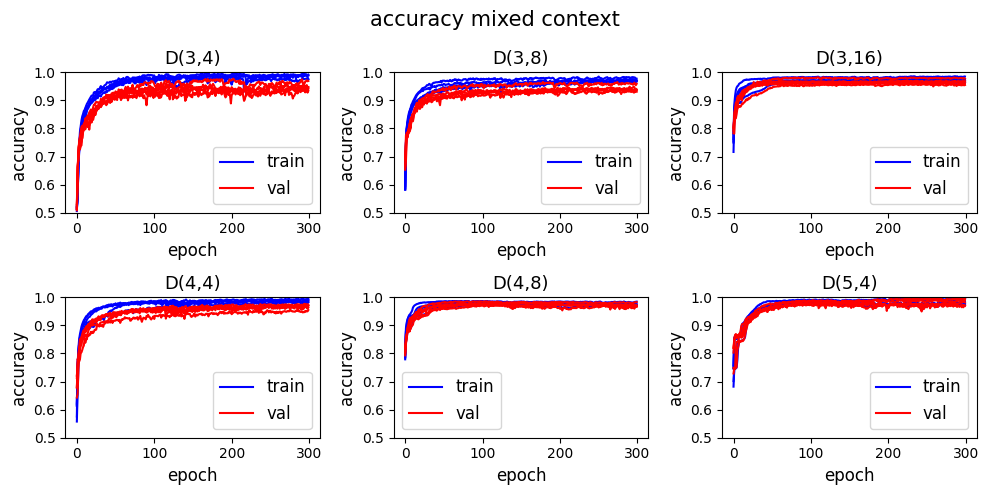

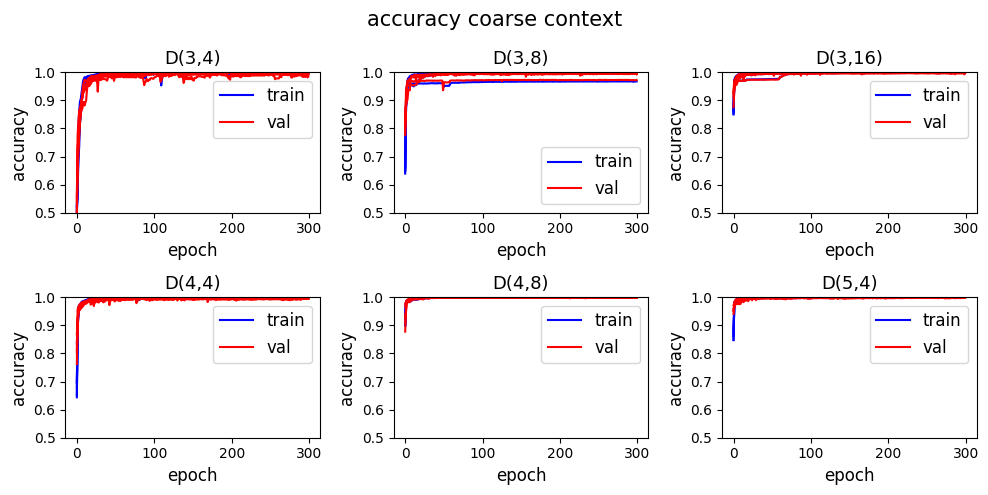

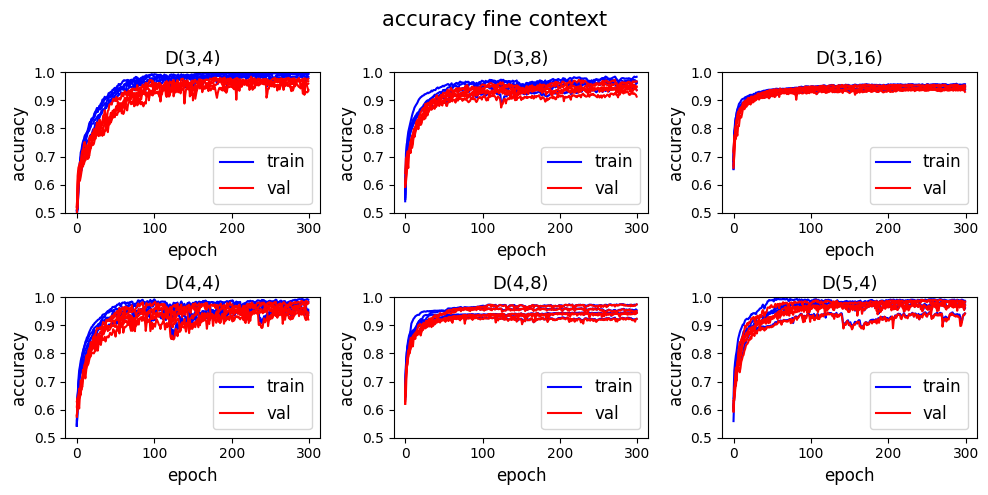

In [ ]:
all_accuracies = load_accuracies(
    paths,
    n_runs=5,
    n_epochs=300,
    val_steps=1,
    granularities=True,
    zero_shot=False,
    context_unaware=context_unaware
)

print(len(all_accuracies['fine_train_acc']))
print(all_accuracies.keys())

plot_name_map = {
    'coarse': 'coarse context',
    'fine': 'fine context',
    'mixed': 'mixed fullcontext',
    'sampled_context': 'mixed context',
}

for g in granularity_list:
    plot_name = plot_name_map.get(g, g)

    plot_training_trajectory(
        all_accuracies[f'{g}_train_acc'],
        all_accuracies[f'{g}_val_acc'],
        ylim=(0.5, 1),
        steps=(1, 1),
        suptitle=f'accuracy {plot_name}',
        figsize=(10, 5)
    )

### Learning speed

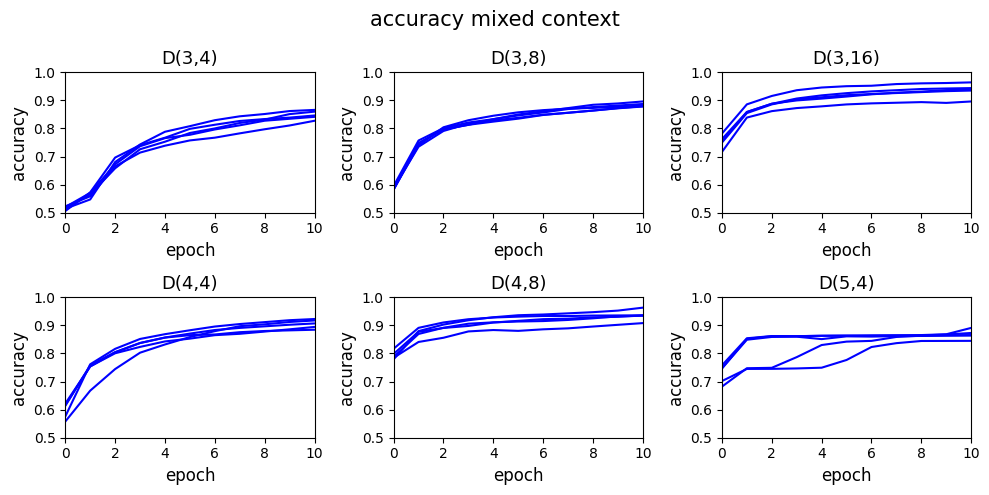

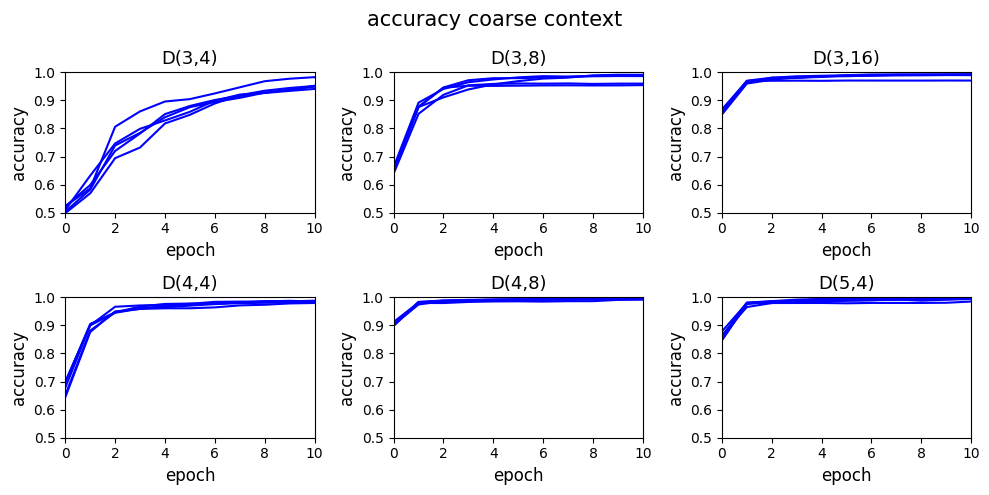

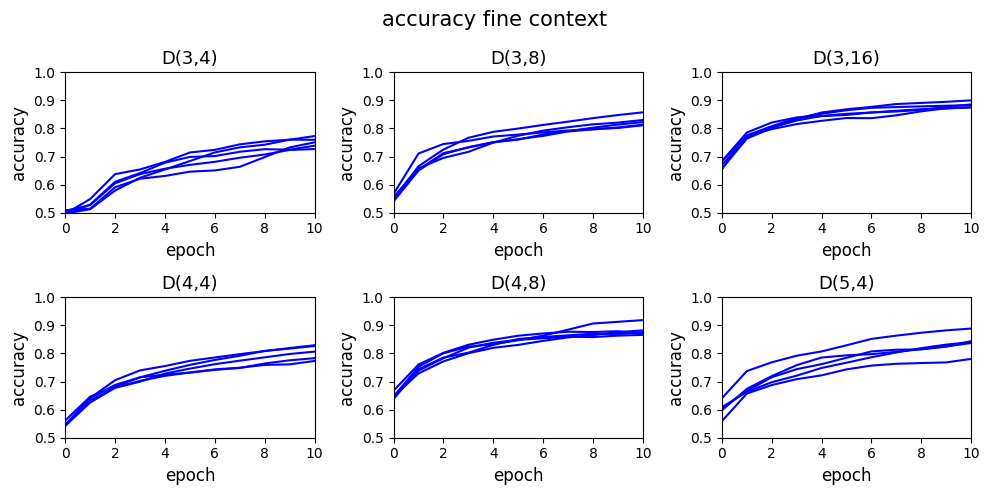

In [ ]:
all_accuracies = load_accuracies(
    paths,
    n_runs=5,
    n_epochs=300,
    val_steps=1,
    granularities=True,
    zero_shot=False,
    context_unaware=context_unaware
)

plot_name_map = {
    'coarse': 'coarse context',
    'fine': 'fine context',
    'mixed': 'mixed full context',
    'sampled_context': 'mixed context',
}

for g in granularity_list:
    plot_name = plot_name_map.get(g, g)

    titles = []
    for d in datasets:
        titles.append('D' + d + ' ' + plot_name)

    plot_training_trajectory(
        all_accuracies[f'{g}_train_acc'],
        all_accuracies[f'{g}_val_acc'],
        ylim=(0.5, 1),
        xlim=(0, 10),
        steps=(1, 1),
        train_only=True,
        figsize=(10, 5),
        suptitle='accuracy ' + plot_name
    )

plt.show()

### Final accuracies 
Final accuracies heatmap plot + get accuracy means and sds for table representation.

In [10]:
##### heatmap for train and validation with different granularities:
all_accuracies = load_accuracies(paths, n_runs=5, n_epochs=300, granularities = True, val_steps=1, zero_shot=False, context_unaware=False)
accuracies_grans = []
test_accuracies_grans = []
conds = ['train', 'val']

for g in granularity_list:
    for c in conds:
        accuracies_grans.append(all_accuracies[str(g)+'_' + c + '_acc'])
        #print(all_accuracies[str(g)+'_' + c + '_acc'], '\n\n')


for g in granularity_list:
    test_accuracies_grans.append(all_accuracies[str(g)+'_test_acc'])

#print('granularities',granularity_list)

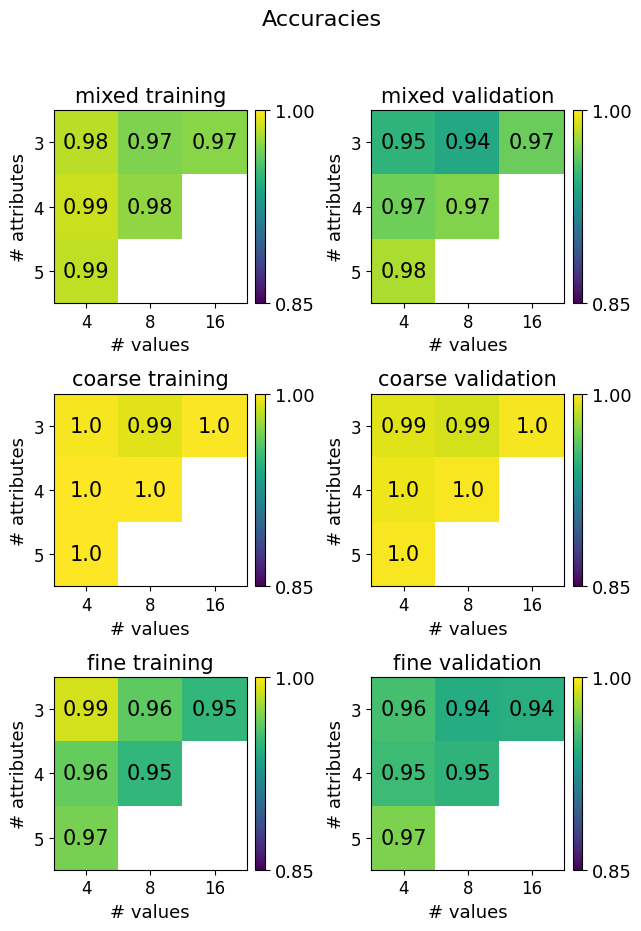

In [43]:
titles = []
conds = ['training', 'validation']

plot_name_map = {
    'coarse': 'coarse',
    'fine': 'fine',
    'mixed': 'mixed full',
    'sampled_context': 'mixed',
}

for g in granularity_list:
    plot_name = plot_name_map.get(g, g)

    for c in conds:
        titles.append(plot_name + ' ' + c)

plot_heatmap(
    accuracies_grans,
    'mean',
    plot_dims=(3, 2),
    ylims=(0.85, 1.0),
    titles=titles,
    figsize=(6.5, 9),
    suptitle='Accuracies',
    fontsize=15
)

In [13]:
for gran in granularity_list:
    print(gran + ' granularity: ')

    final_accuracies_train = {}
    final_accuracies_val = {}

    for i, d in enumerate(datasets):
        gather_train_accuracies = []
        gather_val_accuracies = []
        for run in range(5):
            gather_train_accuracies.append(all_accuracies[gran +'_train_acc'][i][run][-1])
            gather_val_accuracies.append(all_accuracies[gran +'_val_acc'][i][run][-1])

        final_accuracies_train[d] = (round(np.mean(gather_train_accuracies), 3), round(np.std(gather_train_accuracies), 3))
        final_accuracies_val[d] = (round(np.mean(gather_val_accuracies), 3), round(np.std(gather_val_accuracies), 3))

    print('final training accuracy:', final_accuracies_train)
    print('final validation accuracy',final_accuracies_val, '\n')


sampled_context granularity: 
final training accuracy: {'(3,4)': (0.984, 0.007), '(3,8)': (0.971, 0.003), '(3,16)': (0.974, 0.007), '(4,4)': (0.988, 0.004), '(4,8)': (0.975, 0.005), '(5,4)': (0.986, 0.009)}
final validation accuracy {'(3,4)': (0.947, 0.012), '(3,8)': (0.94, 0.01), '(3,16)': (0.966, 0.008), '(4,4)': (0.967, 0.007), '(4,8)': (0.972, 0.006), '(5,4)': (0.982, 0.01)} 

coarse granularity: 
final training accuracy: {'(3,4)': (0.998, 0.003), '(3,8)': (0.993, 0.013), '(3,16)': (0.999, 0.001), '(4,4)': (1.0, 0.0), '(4,8)': (1.0, 0.0), '(5,4)': (1.0, 0.0)}
final validation accuracy {'(3,4)': (0.993, 0.004), '(3,8)': (0.99, 0.009), '(3,16)': (0.998, 0.001), '(4,4)': (0.996, 0.001), '(4,8)': (0.999, 0.0), '(5,4)': (0.999, 0.0)} 

fine granularity: 
final training accuracy: {'(3,4)': (0.99, 0.007), '(3,8)': (0.963, 0.015), '(3,16)': (0.949, 0.007), '(4,4)': (0.964, 0.019), '(4,8)': (0.949, 0.016), '(5,4)': (0.969, 0.016)}
final validation accuracy {'(3,4)': (0.956, 0.017), '(3,8)':

#### Accuracies: Boostrapped CIs

In [14]:
num_bootstrap_samples = 1000  # Number of bootstrap samples
confidence_level = 0.95      # Desired confidence level 

bootstrap_means = []

# coarse (train, val), mixed (train, val), fine (train, val)
for i in range(len(accuracies_grans)):
    for _ in range(num_bootstrap_samples):
        bootstrap_sample = [random.choice(accuracies_grans[i]) for _ in range(len(accuracies_grans[i]))]
        bootstrap_mean = np.mean(bootstrap_sample)
        bootstrap_means.append(bootstrap_mean)

    # Calculate the lower and upper percentiles of the bootstrap means to construct the confidence interval
    alpha = (1 - confidence_level) / 2
    lower_percentile = np.percentile(bootstrap_means, 100 * alpha)
    upper_percentile = np.percentile(bootstrap_means, 100 * (1 - alpha))
    #for i in bootstrap_means:
    if i % 2 == 0:
        print('train ', end = '')
    elif  i % 2 == 1 :
        print('valid ', end = '')
    if i <= 1:
        print (granularity_list[0] + ': ',  end = '' )
    elif i <= 3 :
        print (granularity_list[1] + ': ', end = '')
    elif i >= 4 :
        print (granularity_list[2] + ': ',  end = '')

    print(f" Bootstrap Confidence Interval ({100*confidence_level}%): ({lower_percentile}, {upper_percentile}), Mean: {np.mean(bootstrap_means)}")

train sampled_context:  Bootstrap Confidence Interval (95.0%): (0.9610918820707335, 0.9709054694904221), Mean: 0.9665102663335006
valid sampled_context:  Bootstrap Confidence Interval (95.0%): (0.93552525693708, 0.9705926770435439), Mean: 0.9572246990284987
train coarse:  Bootstrap Confidence Interval (95.0%): (0.9373976972301801, 0.9970896085638139), Mean: 0.9698190671236173
valid coarse:  Bootstrap Confidence Interval (95.0%): (0.9383639117413097, 0.9970246641058889), Mean: 0.9755676832370568
train fine:  Bootstrap Confidence Interval (95.0%): (0.9383011738260587, 0.9969173387653297), Mean: 0.9690926082174439
valid fine:  Bootstrap Confidence Interval (95.0%): (0.9234390872254967, 0.9966624606734349), Mean: 0.9621680201285123


### Test accuracies
means and stds

In [15]:
test_accuracies_grans

[array([[0.75159997, 0.75419986, 0.73360002, 0.72740006, 0.80620009],
        [0.70780826, 0.77592456, 0.7905823 , 0.82845896, 0.80339056],
        [0.84748727, 0.87219232, 0.9371922 , 0.87179035, 0.88572729],
        [0.91860008, 0.89432001, 0.8932001 , 0.91736007, 0.91815996],
        [0.97276294, 0.96295345, 0.95512187, 0.96266383, 0.96482855],
        [0.98783213, 0.99450403, 0.97119987, 0.96570408, 0.97850406]]),
 array([[0.92720008, 0.98539996, 0.977     , 0.92920005, 0.96940005],
        [0.90503424, 0.98476028, 0.98541099, 0.98736298, 0.98726028],
        [0.99904877, 0.9957782 , 0.99319935, 0.98896742, 0.99524921],
        [0.99843997, 0.99456006, 0.99792004, 0.971425  , 0.99107999],
        [0.99568218, 0.99743897, 0.99582708, 0.99605566, 0.99703884],
        [0.99863201, 0.99544805, 0.99853611, 0.99698383, 0.9969762 ]]),
 array([[0.63240004, 0.67840004, 0.65799993, 0.60440004, 0.63059998],
        [0.56787664, 0.60143828, 0.66952044, 0.5585959 , 0.55095893],
        [0.67114

In [16]:
for i, d in enumerate(datasets):
    print('\nDataset:', d)
    for g, gran in enumerate(test_accuracies_grans):
        print('Context granularity:', granularity_list[g])
        print('mean:', round(np.mean(gran[i]), 3), ' std:', round(np.std(gran[i]), 3), ' min:', round(np.min(gran[i]), 2), ' max:', round(np.max(gran[i]), 2))


Dataset: (3,4)
Context granularity: sampled_context
mean: 0.755  std: 0.028  min: 0.73  max: 0.81
Context granularity: coarse
mean: 0.958  std: 0.025  min: 0.93  max: 0.99
Context granularity: fine
mean: 0.641  std: 0.025  min: 0.6  max: 0.68

Dataset: (3,8)
Context granularity: sampled_context
mean: 0.781  std: 0.041  min: 0.71  max: 0.83
Context granularity: coarse
mean: 0.97  std: 0.032  min: 0.91  max: 0.99
Context granularity: fine
mean: 0.59  std: 0.043  min: 0.55  max: 0.67

Dataset: (3,16)
Context granularity: sampled_context
mean: 0.883  std: 0.03  min: 0.85  max: 0.94
Context granularity: coarse
mean: 0.994  std: 0.003  min: 0.99  max: 1.0
Context granularity: fine
mean: 0.678  std: 0.038  min: 0.64  max: 0.73

Dataset: (4,4)
Context granularity: sampled_context
mean: 0.908  std: 0.012  min: 0.89  max: 0.92
Context granularity: coarse
mean: 0.991  std: 0.01  min: 0.97  max: 1.0
Context granularity: fine
mean: 0.78  std: 0.046  min: 0.69  max: 0.82

Dataset: (4,8)
Context gra

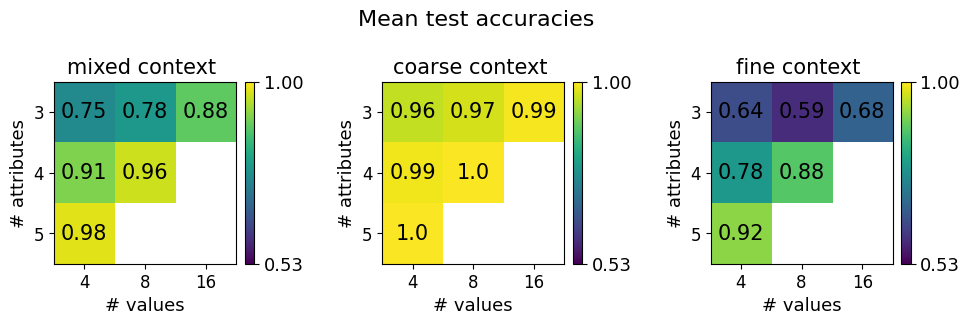

In [ ]:
titles = []
conds = ['test']

plot_name_map = {
    'coarse': 'coarse context',
    'fine': 'fine context',
    'mixed': 'mixed full context',
    'sampled_context': 'mixed context',
}

for g in granularity_list:
    plot_name = plot_name_map.get(g, g)

    for c in conds:
        titles.append(plot_name + ' ' )

plot_heatmap(
    test_accuracies_grans,
    'mean',
    plot_dims=(1, 3),
    ylims=(0.53, 1.0),
    titles=titles,
    suptitle='Mean test accuracies',
    fontsize=15,
    figsize=(10, 3)
)

## Entropy scores

c:\Users\Colab\Documents\GitHub\context-granularity\utils\load_results.py:400: VisibleDeprecationWarning: Creating an ndarray from ragged nested sequences (which is a list-or-tuple of lists-or-tuples-or ndarrays with different lengths or shapes) is deprecated. If you meant to do this, you must specify 'dtype=object' when creating the ndarray.
  result_dict[key] = np.array(result_dict[key])
c:\Users\Colab\Documents\GitHub\context-granularity\utils\load_results.py:400: VisibleDeprecationWarning: Creating an ndarray from ragged nested sequences (which is a list-or-tuple of lists-or-tuples-or ndarrays with different lengths or shapes) is deprecated. If you meant to do this, you must specify 'dtype=object' when creating the ndarray.
  result_dict[key] = np.array(result_dict[key])
c:\Users\Colab\Documents\GitHub\context-granularity\utils\load_results.py:400: VisibleDeprecationWarning: Creating an ndarray from ragged nested sequences (which is a list-or-tuple of lists-or-tuples-or ndarrays wi

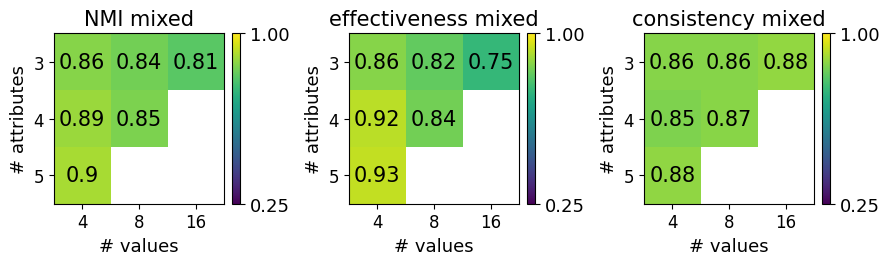

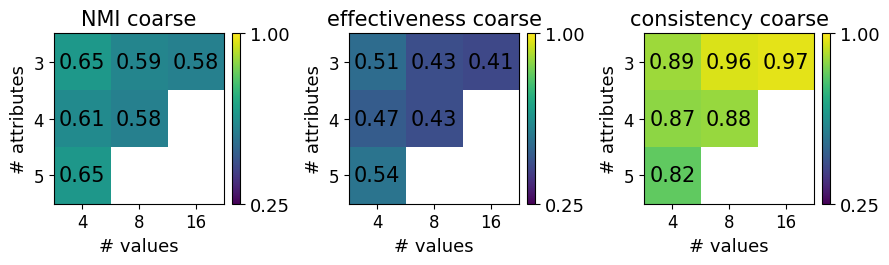

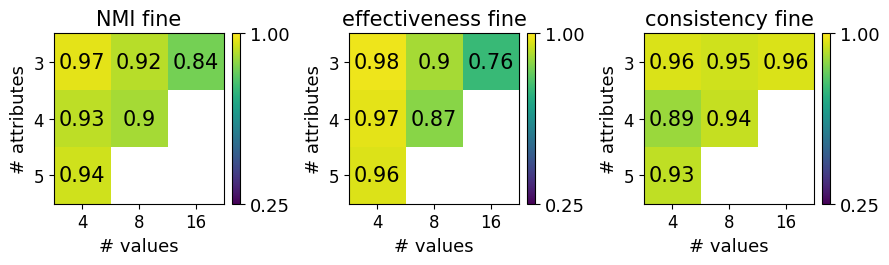

In [ ]:
plot_name_map = {
    'coarse': 'coarse',
    'fine': 'fine',
    'mixed': 'mixed full',
    'sampled_context': 'mixed',
}

for g in granularity_list:
    plot_name = plot_name_map.get(g, g)

    entropy_scores = load_entropies(
        paths,
        context_unaware=False,
        granularity=g
    )

    entropies = [
        entropy_scores['NMI'],
        entropy_scores['effectiveness'],
        entropy_scores['consistency']
    ]

    plot_heatmap(
        entropies,
        'mean',
        plot_dims=(1, 3),
        ylims=(0.25, 1.0),
        figsize=(9, 3),
        titles=(
            'NMI ' + plot_name,
            'effectiveness ' + plot_name,
            'consistency ' + plot_name
        ),
        fontsize=15
    )

c:\Users\Colab\Documents\GitHub\context-granularity\utils\load_results.py:400: VisibleDeprecationWarning: Creating an ndarray from ragged nested sequences (which is a list-or-tuple of lists-or-tuples-or ndarrays with different lengths or shapes) is deprecated. If you meant to do this, you must specify 'dtype=object' when creating the ndarray.
  result_dict[key] = np.array(result_dict[key])
c:\Users\Colab\Documents\GitHub\context-granularity\utils\load_results.py:400: VisibleDeprecationWarning: Creating an ndarray from ragged nested sequences (which is a list-or-tuple of lists-or-tuples-or ndarrays with different lengths or shapes) is deprecated. If you meant to do this, you must specify 'dtype=object' when creating the ndarray.
  result_dict[key] = np.array(result_dict[key])
c:\Users\Colab\Documents\GitHub\context-granularity\utils\load_results.py:400: VisibleDeprecationWarning: Creating an ndarray from ragged nested sequences (which is a list-or-tuple of lists-or-tuples-or ndarrays wi

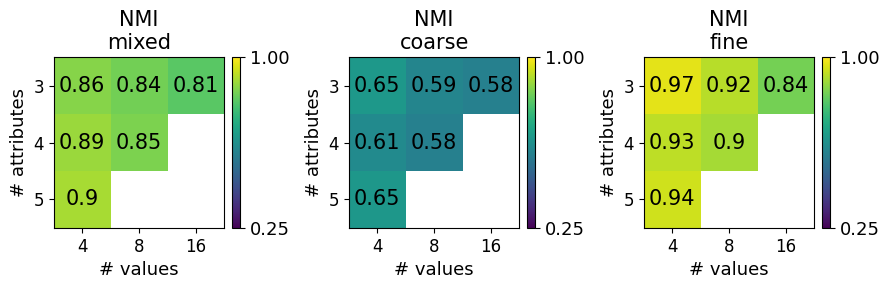

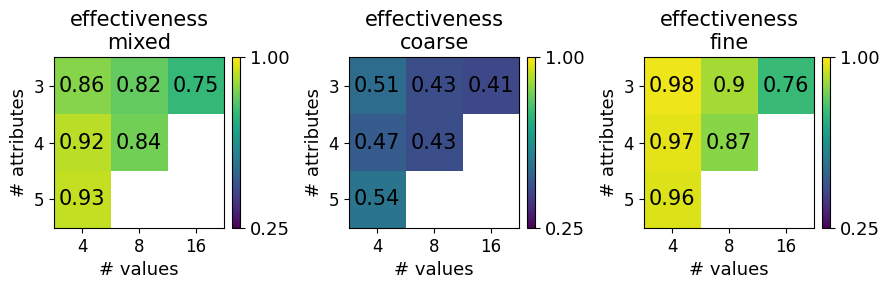

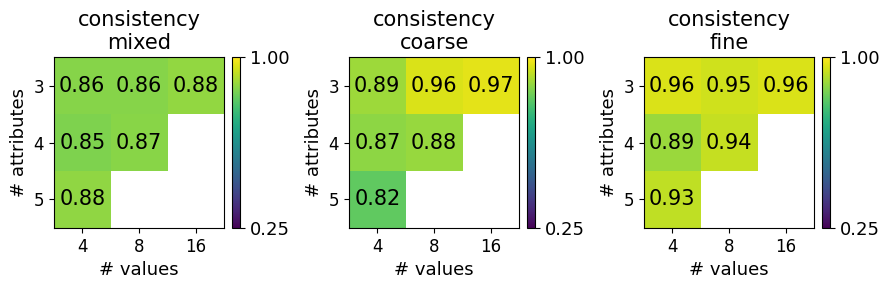

In [42]:
plot_name_map = {
    'coarse': 'coarse',
    'fine': 'fine',
    'mixed': 'mixed full',
    'sampled_context': 'mixed',
}

entropy_keys = ['NMI', 'effectiveness', 'consistency']

for entr in entropy_keys:
    entropy = []
    titles = []

    for g in granularity_list:
        plot_name = plot_name_map.get(g, g)

        entropy_scores = load_entropies(
            paths,
            context_unaware=False,
            granularity=g
        )

        entropy.append(entropy_scores[entr])
        titles.append(entr + '\n' + plot_name)

    plot_heatmap(
        entropy,
        'mean',
        plot_dims=(1, len(granularity_list)),
        ylims=(0.25, 1.0),
        figsize=(9, 3),
        titles=titles,
        fontsize=15
    )

#### Means and stds

In [26]:
for g in granularity_list:
    entropy_scores= load_entropies(paths, context_unaware=False, granularity = g) 
    entropies = [entropy_scores['NMI'], entropy_scores['effectiveness'], entropy_scores['consistency']]  
    entropy_dict = {}
    for i, score in enumerate(list(entropy_scores.keys())[:3]):
        results = entropies[i]
        mean = np.nanmean(results, axis=-1)
        sd = np.std(results, axis=-1)
        for idx, d in enumerate(datasets):
            entropy_dict[d + score] = (round(mean[idx], 3), round(sd[idx], 3))
    print(g + ' context condition\n', entropy_dict, '\n')

sampled_context context condition
 {'(3,4)NMI': (0.863, 0.018), '(3,8)NMI': (0.84, 0.024), '(3,16)NMI': (0.807, 0.032), '(4,4)NMI': (0.887, 0.012), '(4,8)NMI': (0.853, 0.016), '(5,4)NMI': (0.903, 0.03), '(3,4)effectiveness': (0.864, 0.038), '(3,8)effectiveness': (0.82, 0.044), '(3,16)effectiveness': (0.749, 0.058), '(4,4)effectiveness': (0.923, 0.021), '(4,8)effectiveness': (0.84, 0.016), '(5,4)effectiveness': (0.931, 0.035), '(3,4)consistency': (0.864, 0.014), '(3,8)consistency': (0.863, 0.011), '(3,16)consistency': (0.877, 0.006), '(4,4)consistency': (0.854, 0.017), '(4,8)consistency': (0.867, 0.016), '(5,4)consistency': (0.876, 0.028)} 

coarse context condition
 {'(3,4)NMI': (0.651, 0.017), '(3,8)NMI': (0.592, 0.036), '(3,16)NMI': (0.577, 0.025), '(4,4)NMI': (0.608, 0.026), '(4,8)NMI': (0.578, 0.01), '(5,4)NMI': (0.648, 0.025), '(3,4)effectiveness': (0.514, 0.025), '(3,8)effectiveness': (0.43, 0.042), '(3,16)effectiveness': (0.412, 0.028), '(4,4)effectiveness': (0.468, 0.034), '(4,

c:\Users\Colab\Documents\GitHub\context-granularity\utils\load_results.py:400: VisibleDeprecationWarning: Creating an ndarray from ragged nested sequences (which is a list-or-tuple of lists-or-tuples-or ndarrays with different lengths or shapes) is deprecated. If you meant to do this, you must specify 'dtype=object' when creating the ndarray.
  result_dict[key] = np.array(result_dict[key])


#### Bootstraped CIs

In [27]:
num_bootstrap_samples = 1000  # Number of bootstrap samples
confidence_level = 0.95      # Desired confidence level 

for g in granularity_list:
    entropy_scores= load_entropies(paths, context_unaware=False, granularity = g) 
    entropies = [entropy_scores['NMI'], entropy_scores['effectiveness'], entropy_scores['consistency']]  
    entropies_bootstrapped = {}
    bootstrap_means = []

    for i in range(len(entropies)):
        score = list(entropy_scores.keys())[i]
        for idx, d in enumerate(datasets):
            for _ in range(num_bootstrap_samples):
                bootstrap_sample = [random.choice(entropies[i][idx]) for _ in range(len(entropies[i][idx]))]
                bootstrap_mean = np.mean(bootstrap_sample)
                bootstrap_means.append(bootstrap_mean)

            # Calculate the lower and upper percentiles of the bootstrap means to construct the confidence interval
            alpha = (1 - confidence_level) / 2
            lower_percentile = np.percentile(bootstrap_means, 100 * alpha)
            upper_percentile = np.percentile(bootstrap_means, 100 * (1 - alpha))
            entropies_bootstrapped[d + score] = (round(lower_percentile,2), round(upper_percentile,2)), round(np.mean(bootstrap_means),2)
    print('Bootstrapped Entropies', g, 'context condition')
    print(entropies_bootstrapped)

Bootstrapped Entropies sampled_context context condition
{'(3,4)NMI': ((0.85, 0.88), 0.86), '(3,8)NMI': ((0.82, 0.88), 0.85), '(3,16)NMI': ((0.79, 0.87), 0.84), '(4,4)NMI': ((0.79, 0.89), 0.85), '(4,8)NMI': ((0.79, 0.89), 0.85), '(5,4)NMI': ((0.79, 0.92), 0.86), '(3,4)effectiveness': ((0.79, 0.91), 0.86), '(3,8)effectiveness': ((0.79, 0.91), 0.85), '(3,16)effectiveness': ((0.73, 0.91), 0.84), '(4,4)effectiveness': ((0.73, 0.93), 0.85), '(4,8)effectiveness': ((0.73, 0.93), 0.85), '(5,4)effectiveness': ((0.73, 0.94), 0.86), '(3,4)consistency': ((0.73, 0.94), 0.86), '(3,8)consistency': ((0.74, 0.94), 0.86), '(3,16)consistency': ((0.74, 0.94), 0.86), '(4,4)consistency': ((0.74, 0.94), 0.86), '(4,8)consistency': ((0.74, 0.94), 0.86), '(5,4)consistency': ((0.75, 0.94), 0.86)}
Bootstrapped Entropies coarse context condition
{'(3,4)NMI': ((0.63, 0.67), 0.65), '(3,8)NMI': ((0.57, 0.66), 0.62), '(3,16)NMI': ((0.56, 0.66), 0.61), '(4,4)NMI': ((0.56, 0.66), 0.61), '(4,8)NMI': ((0.56, 0.66), 0.6), 

In [28]:
num_bootstrap_samples = 1000  # Number of bootstrap samples
confidence_level = 0.95      # Desired confidence level 

for g in granularity_list:
    entropy_scores= load_entropies(paths, context_unaware=False, granularity = g) 
    entropies = [entropy_scores['NMI'], entropy_scores['effectiveness'], entropy_scores['consistency']]  
    entropies_bootstrapped = {}
    bootstrap_means = []

    for i in range(len(entropies)):
        score = list(entropy_scores.keys())[i]
        
        for _ in range(num_bootstrap_samples):
            bootstrap_sample = [random.choice(entropies[i]) for _ in range(len(entropies[i]))]
            bootstrap_mean = np.mean(bootstrap_sample)
            bootstrap_means.append(bootstrap_mean)

        # Calculate the lower and upper percentiles of the bootstrap means to construct the confidence interval
        alpha = (1 - confidence_level) / 2
        lower_percentile = np.percentile(bootstrap_means, 100 * alpha)
        upper_percentile = np.percentile(bootstrap_means, 100 * (1 - alpha))
        entropies_bootstrapped[score] = (round(lower_percentile,2), round(upper_percentile,2)), round(np.mean(bootstrap_means),2)
    print('Bootstrapped Entropies', g, 'context condition')
    print(entropies_bootstrapped)

Bootstrapped Entropies sampled_context context condition
{'NMI': ((0.83, 0.88), 0.86), 'effectiveness': ((0.81, 0.9), 0.86), 'consistency': ((0.82, 0.89), 0.86)}
Bootstrapped Entropies coarse context condition
{'NMI': ((0.59, 0.63), 0.61), 'effectiveness': ((0.44, 0.63), 0.54), 'consistency': ((0.44, 0.93), 0.66)}
Bootstrapped Entropies fine context condition
{'NMI': ((0.88, 0.95), 0.92), 'effectiveness': ((0.85, 0.96), 0.91), 'consistency': ((0.86, 0.95), 0.92)}


In [32]:
# prepare data for Bayesian estimation
for g in granularity_list:

    entropy_scores= load_entropies(paths, context_unaware=False, granularity = g) 
    df_NMI = pd.DataFrame(entropy_scores['NMI'], columns=range(0,5), index=datasets).reset_index(names='dataset')
    df_NMI = pd.melt(df_NMI, id_vars=['dataset'], value_vars=range(0,5), var_name='run', value_name='NMI')
    df_effectiveness = pd.DataFrame(entropy_scores['effectiveness'], columns=range(0,5), index=datasets).reset_index(names='dataset')
    df_effectiveness = pd.melt(df_effectiveness, id_vars=['dataset'], value_vars=range(0,5), var_name='run', value_name='effectiveness')
    df_consistency = pd.DataFrame(entropy_scores['consistency'], columns=range(0,5), index=datasets).reset_index(names='dataset')
    df_consistency = pd.melt(df_consistency, id_vars=['dataset'], value_vars=range(0,5), var_name='run', value_name='consistency')
    
    data = pd.concat([df_NMI, df_effectiveness, df_consistency], ignore_index=True)
    data = pd.melt(data, id_vars=['dataset', 'run'], value_vars=['NMI', 'effectiveness', 'consistency'], var_name='entropy_score',
                   value_name='value')
    if g == 'fine':
        data['condition'] = 'fine'
        df_fine = data
    elif g == 'sampled_context':
        data['condition'] = 'sampled_context'
        df_mixed = data
    else:
        data['condition'] = 'coarse'
        df_coarse = data

df = pd.concat([df_fine, df_mixed, df_coarse], ignore_index=True).dropna()
df.to_csv('BayesianAnalysis/data_for_R.csv', index=False)

c:\Users\Colab\Documents\GitHub\context-granularity\utils\load_results.py:400: VisibleDeprecationWarning: Creating an ndarray from ragged nested sequences (which is a list-or-tuple of lists-or-tuples-or ndarrays with different lengths or shapes) is deprecated. If you meant to do this, you must specify 'dtype=object' when creating the ndarray.
  result_dict[key] = np.array(result_dict[key])
c:\Users\Colab\Documents\GitHub\context-granularity\utils\load_results.py:400: VisibleDeprecationWarning: Creating an ndarray from ragged nested sequences (which is a list-or-tuple of lists-or-tuples-or ndarrays with different lengths or shapes) is deprecated. If you meant to do this, you must specify 'dtype=object' when creating the ndarray.
  result_dict[key] = np.array(result_dict[key])
c:\Users\Colab\Documents\GitHub\context-granularity\utils\load_results.py:400: VisibleDeprecationWarning: Creating an ndarray from ragged nested sequences (which is a list-or-tuple of lists-or-tuples-or ndarrays wi

### Concept-dependent

### Plotting concept level

In [34]:
entropy_dict_hierarchical = {}

for g in granularity_list:
    data_list, run_list, level_list = [], [], []
    NMI_hierarchical, effectiveness_hierarchical, consistency_hierarchical = [], [], []

    for d, data in enumerate(datasets):
        for run in range(5):

            if g == 'mixed':
                scores_path = paths[d] + '/' + setting + '/' + str(run) + '/entropy_scores.pkl'

            elif g == 'sampled_context':
                scores_path = paths[d] + '/' + setting + '/sampled_context/' + str(run) + '/entropy_scores.pkl'

            else:
                scores_path = paths[d] + '/' + setting + '/granularity_' + g + '/' + str(run) + '/entropy_scores.pkl'

            scores = pickle.load(open(scores_path, 'rb'))

            for l, level in enumerate([1, 2, 3, 4, 5]):

                data_list.append(data)
                run_list.append(run)
                level_list.append(level)

                try:
                    NMI_hierarchical.append(scores['normalized_mutual_info_hierarchical'][l])
                    effectiveness_hierarchical.append(scores['effectiveness_hierarchical'][l])
                    consistency_hierarchical.append(scores['consistency_hierarchical'][l])
                except IndexError:
                    NMI_hierarchical.append(np.nan)
                    effectiveness_hierarchical.append(np.nan)
                    consistency_hierarchical.append(np.nan)

    entropy_dict_hierarchical['data_' + g] = data_list
    entropy_dict_hierarchical['level_' + g] = level_list
    entropy_dict_hierarchical['run_' + g] = run_list
    entropy_dict_hierarchical['NMI_' + g] = NMI_hierarchical
    entropy_dict_hierarchical['Effectiveness_' + g] = effectiveness_hierarchical
    entropy_dict_hierarchical['Consistency_' + g] = consistency_hierarchical

# print(entropy_dict_hierarchical.keys())

In [35]:
all_hierarchical = {}
for g in granularity_list:
    all_hierarchical[g] = {}
    all_hierarchical[g]['metric'] = ['Effectiveness_'+g] * 150 + ['Consistency_'+g] * 150 + ['NMI_'+g] * 150 # change to 25 for one dataset
    all_hierarchical[g]['value'] = (entropy_dict_hierarchical['Effectiveness_'+g] + 
                                entropy_dict_hierarchical['Consistency_'+g] +
                                entropy_dict_hierarchical['NMI_'+g])
    all_hierarchical[g]['level'] = entropy_dict_hierarchical['level_'+g] * 3

print(all_hierarchical.keys())


dict_keys(['sampled_context', 'coarse', 'fine'])


C:\Users\Colab\AppData\Local\Temp\ipykernel_9392\2084296726.py:13: UserWarning: 

The `scale` parameter is deprecated and will be removed in v0.15.0. You can now control the size of each plot element using matplotlib `Line2D` parameters (e.g., `linewidth`, `markersize`, etc.).

  ax = sns.pointplot(


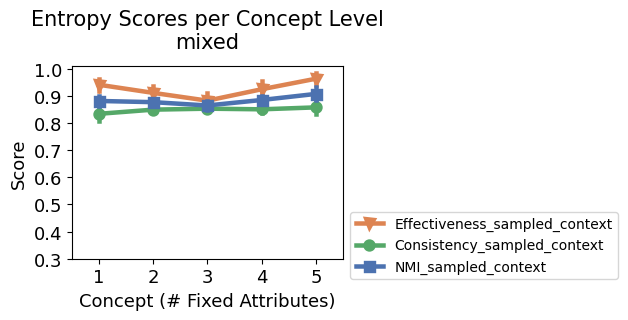

C:\Users\Colab\AppData\Local\Temp\ipykernel_9392\2084296726.py:13: UserWarning: 

The `scale` parameter is deprecated and will be removed in v0.15.0. You can now control the size of each plot element using matplotlib `Line2D` parameters (e.g., `linewidth`, `markersize`, etc.).

  ax = sns.pointplot(


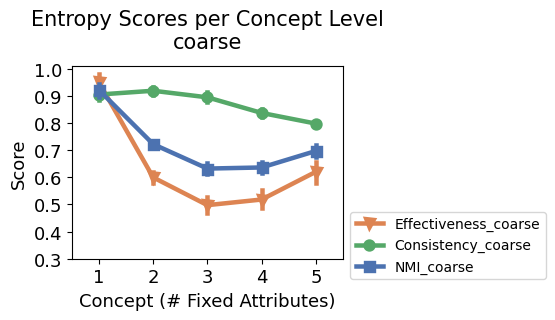

C:\Users\Colab\AppData\Local\Temp\ipykernel_9392\2084296726.py:13: UserWarning: 

The `scale` parameter is deprecated and will be removed in v0.15.0. You can now control the size of each plot element using matplotlib `Line2D` parameters (e.g., `linewidth`, `markersize`, etc.).

  ax = sns.pointplot(


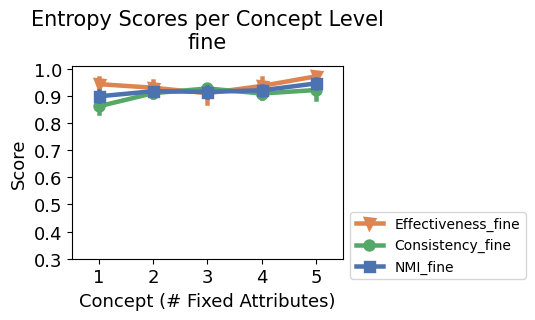

In [37]:
plot_name_map = {
    'coarse': 'coarse',
    'fine': 'fine',
    'mixed': 'mixed_full',
    'sampled_context': 'mixed',
}

for g in granularity_list:
    plot_name = plot_name_map.get(g, g)

    plt.figure(figsize=(3.5, 2.5))

    ax = sns.pointplot(
        x='level',
        y='value',
        data=all_hierarchical[g],
        hue='metric',
        errorbar=('ci', 95),
        markers=['v', 'o', 's'],
        palette=sns.color_palette([
            (0.8666666666666667, 0.5176470588235295, 0.3215686274509804),
            (0.3333333333333333, 0.6588235294117647, 0.40784313725490196),
            (0.2980392156862745, 0.4470588235294118, 0.6901960784313725)
        ]),
        scale=1.2
    )

    plt.ylabel('Score', fontsize=13)
    plt.title(
        'Entropy Scores per Concept Level\n' + plot_name,
        fontsize=15,
        y=1.05
    )

    plt.ylim([0.3, 1.01])
    plt.xticks(ticks=[0, 1, 2, 3, 4], labels=[1, 2, 3, 4, 5], fontsize=13)
    plt.yticks(
        ticks=[0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1.0],
        fontsize=13
    )

    plt.xlabel('Concept (# Fixed Attributes)', fontsize=13)
    plt.legend(loc='upper left', bbox_to_anchor=(1, 0.28))

    plt.show()

In [39]:
# prepare data for Bayesian estimation
for g in granularity_list:

    entropy_scores= load_entropies(paths, context_unaware=False, granularity = g) 
    df_NMI = pd.DataFrame(entropy_scores['NMI_hierarchical'], columns=range(0,5), index=datasets).reset_index(names='dataset')
    df_NMI = pd.melt(df_NMI, id_vars=['dataset'], value_vars=range(0,5), var_name='run', value_name='NMI')
    
    rows = []
    for idx, row in df_NMI.iterrows():
        for hierarchy_level, value in enumerate(row['NMI']):
            #print(idx, hierarchy_level, value)
            rows.append({'dataset': row['dataset'], 'run': row['run'], 'value': value, 'hierarchy_level': hierarchy_level})
    data = pd.DataFrame(rows)
    
    if g == 'fine':
        data['condition'] = 'fine'
        df_fine = data
    elif g == 'mixed':
        data['condition'] = 'bootstrap_sample'
        df_mixed = data
    else:
        data['condition'] = 'coarse'
        df_coarse = data

df = pd.concat([df_fine, df_mixed, df_coarse], ignore_index=True).dropna()

print(df)

df.to_csv('BayesianAnalysis/data_for_R_NMI_hierarchical.csv', index=False)

Empty DataFrame
Columns: [dataset, run, value, hierarchy_level, condition, entropy_score]
Index: []


c:\Users\Colab\Documents\GitHub\context-granularity\utils\load_results.py:400: VisibleDeprecationWarning: Creating an ndarray from ragged nested sequences (which is a list-or-tuple of lists-or-tuples-or ndarrays with different lengths or shapes) is deprecated. If you meant to do this, you must specify 'dtype=object' when creating the ndarray.
  result_dict[key] = np.array(result_dict[key])
c:\Users\Colab\Documents\GitHub\context-granularity\utils\load_results.py:400: VisibleDeprecationWarning: Creating an ndarray from ragged nested sequences (which is a list-or-tuple of lists-or-tuples-or ndarrays with different lengths or shapes) is deprecated. If you meant to do this, you must specify 'dtype=object' when creating the ndarray.
  result_dict[key] = np.array(result_dict[key])
c:\Users\Colab\Documents\GitHub\context-granularity\utils\load_results.py:400: VisibleDeprecationWarning: Creating an ndarray from ragged nested sequences (which is a list-or-tuple of lists-or-tuples-or ndarrays wi

In [40]:
# prepare data for Bayesian estimation
for g in granularity_list:

    entropy_scores= load_entropies(paths, context_unaware=False, granularity = g) 
    df_NMI = pd.DataFrame(entropy_scores['effectiveness_hierarchical'], columns=range(0,5), index=datasets).reset_index(names='dataset')
    df_NMI = pd.melt(df_NMI, id_vars=['dataset'], value_vars=range(0,5), var_name='run', value_name='effectiveness')
    
    rows = []
    for idx, row in df_NMI.iterrows():
        for hierarchy_level, value in enumerate(row['effectiveness']):
            #print(idx, hierarchy_level, value)
            rows.append({'dataset': row['dataset'], 'run': row['run'], 'value': value, 'hierarchy_level': hierarchy_level})
    data = pd.DataFrame(rows)
    
    if g == 'fine':
        data['condition'] = 'fine'
        df_fine = data
    elif g == 'mixed':
        data['condition'] = 'sampled_context'
        df_mixed = data
    else:
        data['condition'] = 'coarse'
        df_coarse = data

df = pd.concat([df_fine, df_mixed, df_coarse], ignore_index=True).dropna()

df.to_csv('BayesianAnalysis/data_for_R_effectiveness_hierarchical.csv', index=False)

c:\Users\Colab\Documents\GitHub\context-granularity\utils\load_results.py:400: VisibleDeprecationWarning: Creating an ndarray from ragged nested sequences (which is a list-or-tuple of lists-or-tuples-or ndarrays with different lengths or shapes) is deprecated. If you meant to do this, you must specify 'dtype=object' when creating the ndarray.
  result_dict[key] = np.array(result_dict[key])
c:\Users\Colab\Documents\GitHub\context-granularity\utils\load_results.py:400: VisibleDeprecationWarning: Creating an ndarray from ragged nested sequences (which is a list-or-tuple of lists-or-tuples-or ndarrays with different lengths or shapes) is deprecated. If you meant to do this, you must specify 'dtype=object' when creating the ndarray.
  result_dict[key] = np.array(result_dict[key])
c:\Users\Colab\Documents\GitHub\context-granularity\utils\load_results.py:400: VisibleDeprecationWarning: Creating an ndarray from ragged nested sequences (which is a list-or-tuple of lists-or-tuples-or ndarrays wi

In [41]:
# prepare data for Bayesian estimation
for g in granularity_list:

    entropy_scores= load_entropies(paths, context_unaware=False, granularity = g) 
    df_NMI = pd.DataFrame(entropy_scores['consistency_hierarchical'], columns=range(0,5), index=datasets).reset_index(names='dataset')
    df_NMI = pd.melt(df_NMI, id_vars=['dataset'], value_vars=range(0,5), var_name='run', value_name='consistency')
    
    rows = []
    for idx, row in df_NMI.iterrows():
        for hierarchy_level, value in enumerate(row['consistency']):
            #print(idx, hierarchy_level, value)
            rows.append({'dataset': row['dataset'], 'run': row['run'], 'value': value, 'hierarchy_level': hierarchy_level})
    data = pd.DataFrame(rows)
    
    if g == 'fine':
        data['condition'] = 'fine'
        df_fine = data
    elif g == 'mixed':
        data['condition'] = 'sampled_context'
        df_mixed = data
    else:
        data['condition'] = 'coarse'
        df_coarse = data

df = pd.concat([df_fine, df_mixed, df_coarse], ignore_index=True).dropna()

df.to_csv('BayesianAnalysis/data_for_R_consistency_hierarchical.csv', index=False)

c:\Users\Colab\Documents\GitHub\context-granularity\utils\load_results.py:400: VisibleDeprecationWarning: Creating an ndarray from ragged nested sequences (which is a list-or-tuple of lists-or-tuples-or ndarrays with different lengths or shapes) is deprecated. If you meant to do this, you must specify 'dtype=object' when creating the ndarray.
  result_dict[key] = np.array(result_dict[key])
c:\Users\Colab\Documents\GitHub\context-granularity\utils\load_results.py:400: VisibleDeprecationWarning: Creating an ndarray from ragged nested sequences (which is a list-or-tuple of lists-or-tuples-or ndarrays with different lengths or shapes) is deprecated. If you meant to do this, you must specify 'dtype=object' when creating the ndarray.
  result_dict[key] = np.array(result_dict[key])
c:\Users\Colab\Documents\GitHub\context-granularity\utils\load_results.py:400: VisibleDeprecationWarning: Creating an ndarray from ragged nested sequences (which is a list-or-tuple of lists-or-tuples-or ndarrays wi

## not updated from now on

### Symbol redundancy

In [60]:

for g in granularity_list:
    symbol_redundancy_dict = {'level': [], 'data set': [], 'run': [], 'symbol frequency': []}
    for d, dataset in enumerate(datasets): 
        for run in range(5):
            if g == 'mixed':
                scores = pickle.load(open(paths[d]  + '/' + setting + '/' + str(run) + '/symbol_redundancy.pkl', 'rb'))
            else:
                 scores = pickle.load(open(paths[d]  + '/' + setting + '/' + 'granularity_' + g + '/' + str(run) + '/symbol_redundancy.pkl', 'rb'))
                
            for level in range(5):
                
                symbol_redundancy_dict['level'].append(level)
                symbol_redundancy_dict['run'].append(run)
                symbol_redundancy_dict['data set'].append(dataset)
                try: 
                    symbol_redundancy_dict['symbol frequency'].append(scores['symbol_redundancy'][level])
                except: 
                    symbol_redundancy_dict['symbol frequency'].append(np.NaN)
    
    plt.figure(figsize=(5,3))
    sns.boxplot(x='level', y='symbol frequency', data=symbol_redundancy_dict, color='gray')
    plt.xticks(ticks=[0,1,2,3,4], labels=[1,2,3,4,5], fontsize=15)
    plt.yticks(ticks=[0, 1, 2], fontsize=15)
    plt.xlabel('# fixed attributes', fontsize=16)
    plt.ylabel('occurrences', fontsize=16)
    plt.title('symbol redundancy' + '\n' + g + ' context condition', fontsize=17, y=1.05)
    plt.show()

FileNotFoundError: [Errno 2] No such file or directory: 'results/(3,4)_game_size_10_vsf_3/standard/granularity_coarse/0/symbol_redundancy.pkl'